In [1]:
random_state_2909 = 2909

# 4 Pre-Processing and Training Data<a id='4_Pre-Processing_and_Training_Data'></a>

## 4.2 Introduction<a id='4.2_Introduction'></a>

## 4.3 Imports<a id='4.3_Imports'></a>

In [2]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import datetime

pd.options.display.max_columns = 999
pd.options.display.max_rows = 999

## 4.4 Functions<a id='4.4_Imports'></a>

In [3]:
#return the first 5 and last 5 rows of this dataframe
def p(df_):
    if df_.shape[0] > 6:
        print(df_.shape)
        return pd.concat([df_.head(), df_.tail()])
    else:
        return df_

def rcp(file_, pd_=None, ic_=None):
    if (pd_ == None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_))
    elif (pd_ != None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_)
    elif (pd_ != None) and (ic_ != None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_, index_col = ic_)
    else:
        return pd.read_csv(os.path.join('..', 'processed_data', file_), index_col = ic_)
    
def rcr(file_, pd_=None):
    if pd_ == None:
        return pd.read_csv(os.path.join('..', 'raw_data', file_))
    else:
        return pd.read_csv(os.path.join('..', 'raw_data', file_), parse_dates=pd_)
    
#sort dataframe by column
def s(df_, column_):
    return df_.sort_values(column_)

#reset index and sort dataframe by column
def sr(df_, column_, ascending_=True):
    df_ = df_.sort_values(column_, ascending=ascending_)
    return df_.reset_index(drop=True)

#print length of list
def pl(list_):
    print(len(list_))
    return list_

#print length of dictionary
def pdc(dict_):
    print(len(dict_))
    return dict_


In [4]:
# This isn't exactly production-grade, but a quick check for development
# These checks can save some head-scratching in development when moving from
# one python environment to another, for example
expected_model_version = '1.0'
model_path = os.path.join('..','models', '172_model_training_trial_2.pkl')
if os.path.exists(model_path):
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    if model.version != expected_model_version:
        print("Expected model version doesn't match version loaded")
    if model.sklearn_version != sklearn_version:
        print("Warning: model created under different sklearn version")
else:
    print("Expected model not found")

/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator DecisionTreeRegressor from version 0.22 when using version 0.23.2. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator RandomForestRegressor from version 0.22 when using version 0.23.2. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator Pipeline from version 0.22 when using version 0.23.2. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(


In [5]:
model_172_model_training_trial_2 = model
model_172_model_training_trial_2

Pipeline(steps=[('randomforestregressor',
                 RandomForestRegressor(criterion='mae', max_depth=5,
                                       min_samples_split=100, n_estimators=200,
                                       random_state=47))])

In [6]:
model_172_model_training_trial_2.set_params

<bound method Pipeline.set_params of Pipeline(steps=[('randomforestregressor',
                 RandomForestRegressor(criterion='mae', max_depth=5,
                                       min_samples_split=100, n_estimators=200,
                                       random_state=47))])>

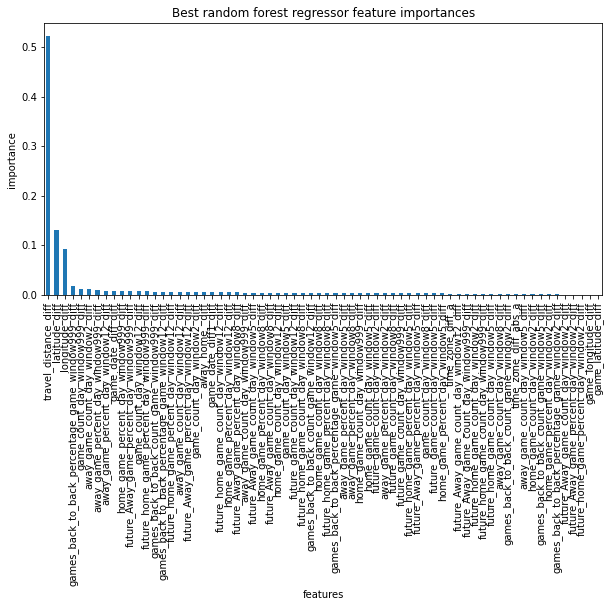

In [7]:
#Code task 27#
#Plot a barplot of the random forest's feature importances,
#assigning the `feature_importances_` attribute of 
#`rf_grid_cv.best_estimator_.named_steps.randomforestregressor` to the name `imps` to then
#create a pandas Series object of the feature importances, with the index given by the
#training data column names, sorting the values in descending order
plt.subplots(figsize=(10, 5))
imps = model_172_model_training_trial_2.named_steps.randomforestregressor.feature_importances_
rf_feat_imps = pd.Series(imps, index=model_172_model_training_trial_2.X_columns).sort_values(ascending=False)
rf_feat_imps.plot(kind='bar')
plt.xlabel('features')
plt.ylabel('importance')
plt.title('Best random forest regressor feature importances');

In [8]:
print(len(rf_feat_imps[0:50]))
rf_feat_imps[0:50]

50


travel_distance_diff                                 0.522727
latitude_diff                                        0.130294
longitude_diff                                       0.092645
games_back_to_back_percentage_game_window999_diff    0.018119
game_count_day_window999_diff                        0.010663
away_game_count_day_window2_diff                     0.010662
away_game_percent_day_window999_diff                 0.008661
away_game_percent_day_window12_diff                  0.008061
game_date_diff_diff                                  0.007776
home_game_percent_day_window999_diff                 0.007652
future_Away_game_percent_day_window999_diff          0.007506
game_count_day_window12_diff                         0.007128
future_home_game_percent_day_window999_diff          0.007013
games_back_to_back_count_game_window999_diff         0.006267
games_back_to_back_percentage_game_window12_diff     0.006137
future_home_game_percent_day_window12_diff           0.005981
away_gam

In [9]:
#get top 50 features of previous model



In [10]:
rf_feat_imps_top_50_list = list(rf_feat_imps[0:50].index)
pl(rf_feat_imps_top_50_list)

50


['travel_distance_diff',
 'latitude_diff',
 'longitude_diff',
 'games_back_to_back_percentage_game_window999_diff',
 'game_count_day_window999_diff',
 'away_game_count_day_window2_diff',
 'away_game_percent_day_window999_diff',
 'away_game_percent_day_window12_diff',
 'game_date_diff_diff',
 'home_game_percent_day_window999_diff',
 'future_Away_game_percent_day_window999_diff',
 'game_count_day_window12_diff',
 'future_home_game_percent_day_window999_diff',
 'games_back_to_back_count_game_window999_diff',
 'games_back_to_back_percentage_game_window12_diff',
 'future_home_game_percent_day_window12_diff',
 'away_game_count_day_window12_diff',
 'future_Away_game_percent_day_window12_diff',
 'game_count_day_window2_diff',
 'away_home__diff',
 'game_date_diff1_diff',
 'future_home_game_count_day_window12_diff',
 'home_game_percent_day_window12_diff',
 'future_Away_game_percent_day_window8_diff',
 'away_game_count_day_window999_diff',
 'future_Away_game_count_day_window5_diff',
 'home_game_p

## 4.5 Load Data<a id='4.5_Load_Data'></a>

In [11]:
df_stats = rcp('53AAprediction_stats_2010_2018.csv', ['game_date'])
p(df_stats)

(10266, 107)


,game_id,TEAM_NAME_a,TEAM_ABBREVIATION_a,TEAM_CITY_a,team_id_a,spread_a,away_home_a,game_date,matchup,season_type,season,TEAM_NAME_b,TEAM_ABBREVIATION_b,TEAM_CITY_b,team_id_b,E_OFF_RATING_cma_diff,OFF_RATING_cma_diff,E_DEF_RATING_cma_diff,DEF_RATING_cma_diff,E_NET_RATING_cma_diff,NET_RATING_cma_diff,AST_PCT_cma_diff,AST_TOV_cma_diff,AST_RATIO_cma_diff,OREB_PCT_cma_diff,DREB_PCT_cma_diff,REB_PCT_cma_diff,E_TM_TOV_PCT_cma_diff,TM_TOV_PCT_cma_diff,EFG_PCT_cma_diff,TS_PCT_cma_diff,USG_PCT_cma_diff,E_USG_PCT_cma_diff,E_PACE_cma_diff,PACE_cma_diff,PACE_PER40_cma_diff,POSS_cma_diff,PIE_cma_diff,duration_minutes_cma_diff,w_pct_cma_diff,min_cma_diff,fgm_cma_diff,fga_cma_diff,fg_pct_cma_diff,fg3m_cma_diff,fg3a_cma_diff,fg3_pct_cma_diff,ftm_cma_diff,fta_cma_diff,ft_pct_cma_diff,oreb_cma_diff,dreb_cma_diff,reb_cma_diff,ast_cma_diff,stl_cma_diff,blk_cma_diff,tov_cma_diff,pf_cma_diff,pts_cma_diff,spread_cma_diff,away_home_cma_diff,E_OFF_RATING_sm_cma_diff,OFF_RATING_sm_cma_diff,E_DEF_RATING_sm_cma_diff,DEF_RATING_sm_cma_diff,E_NET_RATING_sm_cma_diff,NET_RATING_sm_cma_diff,AST_PCT_sm_cma_diff,AST_TOV_sm_cma_diff,AST_RATIO_sm_cma_diff,OREB_PCT_sm_cma_diff,DREB_PCT_sm_cma_diff,REB_PCT_sm_cma_diff,E_TM_TOV_PCT_sm_cma_diff,TM_TOV_PCT_sm_cma_diff,EFG_PCT_sm_cma_diff,TS_PCT_sm_cma_diff,USG_PCT_sm_cma_diff,E_USG_PCT_sm_cma_diff,E_PACE_sm_cma_diff,PACE_sm_cma_diff,PACE_PER40_sm_cma_diff,POSS_sm_cma_diff,PIE_sm_cma_diff,duration_minutes_sm_cma_diff,w_pct_sm_cma_diff,min_sm_cma_diff,fgm_sm_cma_diff,fga_sm_cma_diff,fg_pct_sm_cma_diff,fg3m_sm_cma_diff,fg3a_sm_cma_diff,fg3_pct_sm_cma_diff,ftm_sm_cma_diff,fta_sm_cma_diff,ft_pct_sm_cma_diff,oreb_sm_cma_diff,dreb_sm_cma_diff,reb_sm_cma_diff,ast_sm_cma_diff,stl_sm_cma_diff,blk_sm_cma_diff,tov_sm_cma_diff,pf_sm_cma_diff,pts_sm_cma_diff,spread_sm_cma_diff,away_home_sm_cma_diff
0,21000001,Celtics,BOS,Boston,1610612738,-8,1,2010-10-26,BOS vs. MIA,Regular Season,2010-11,Heat,MIA,Miami,1610612748,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,21000002,Suns,PHX,Phoenix,1610612756,14,0,2010-10-26,PHX vs. POR,Regular Season,2010-11,Trail Blazers,POR,Portland,1610612757,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,21000003,Rockets,HOU,Houston,1610612745,2,0,2010-10-26,HOU vs. LAL,Regular Season,2010-11,Lakers,LAL,Los Angeles,1610612747,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.

In [12]:
df_stats_gitiab_spread = df_stats.loc[:, ['game_id', 'team_id_a', 'team_id_b', 'spread_a']]
p(df_stats_gitiab_spread)

(10266, 4)


,game_id,team_id_a,team_id_b,spread_a
0,21000001,1610612738,1610612748,-8
1,21000002,1610612756,1610612757,14
2,21000003,1610612745,1610612747,2
3,21000009,1610612750,1610612758,1
4,21000006,1610612748,1610612755,-10
10261,41700317,1610612744,1610612745,-9
10262,41700401,1610612739,1610612744,10
10263,41700402,1610612739,1610612744,19
10264,41700403,1610612739,1610612744,8
10265,41700404,1610612739,1610612744,23


In [13]:
df = rcp('72_71C_schedule_location_differences_2010_2018.csv', ['game_date'])
p(df)

(10266, 83)


,game_id,team_id_a,game_date,season,game_time_zone_a,time_zone_a,time_zone_diff_a,time_zone_diff_abs_a,city_proper_metro_Area_a,Country/Region_a,team_id_b,game_time_zone_b,time_zone_b,city_proper_metro_Area_b,Country/Region_b,away_home__diff,latitude_diff,longitude_diff,game_latitude_diff,game_longitude_diff,travel_distance_diff,city_proper_metro_Area_GDP_bil_diff,city_proper_metro_Area_GDP_bil1_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window2_diff,games_back_to_back_count_game_window5_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window2_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,home_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_percent_day_window2_diff,away_game_count_day_window5_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,away_game_count_day_window8_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_Away_game_count_day_window2_diff,future_home_game_count_day_window2_diff,future_game_count_day_window2_diff,future_Away_game_percent_day_window2_diff,future_home_game_percent_day_window2_diff,future_Away_game_count_day_window5_diff,future_home_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_Away_game_count_day_window12_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_Away_game_count_day_window999_diff,future_home_game_count_day_window999_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff
0,21000001,1610612738,2010-10-26,2010-11,America/New_York,America/New_York,0,0,Boston,United States,1610612748,America/New_York,America/New_York,Miami,United States,1.0,16.586081,9.135329,0.0,0.0,-1257.755091,86.070,297.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.0,1.0,0.0,-1.0,1.0,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-0.5,0.5,-1.0,1.0,0.0,-0.333333,0.333333,-1.0,0.0,-1.0,-0.100000,0.100000,-2.0,1.0,-1.0,-0.238095,0.238095,0.0,0.0,0.0,0.000000,0.000000
1,21000002,1610612756,2010-10-26,2010-11,America/Los_Angeles,America/Phoenix,0,0,Phoenix,United States,1610612757,America/Los_Angeles,America/Los_Angeles,Portland,United States,-1.0,-12.071810,10.600053,0.0,0.0,1005.606855,90.792,448.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,-1.0,0.0,1.0,-1.0,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,0.0,-1.0,-1.0,0.5,-0.5,0.0,0.0,0.0,0.000000,0.000000,-2.0,0.0,-2.0,-0.133333,0.133333,-2.0,0.0,-2.0,-0.171429,0.171429,0.0,0.0,0.0,0.000000,0.000000
2,21000003,1610612745,2010-10-26,2010-11,America/Los_Angeles,America/Chicago,-2,2,Houston,United States,1610612747,America/Los_Angeles,America/Los_Angeles,Los Angeles,United States,-1.0,-4.29

In [14]:
#merge
df = pd.merge(df_stats_gitiab_spread,
              df,
              on=['game_id', 'team_id_a', 'team_id_b'],)
p(df)

(10266, 84)


,game_id,team_id_a,team_id_b,spread_a,game_date,season,game_time_zone_a,time_zone_a,time_zone_diff_a,time_zone_diff_abs_a,city_proper_metro_Area_a,Country/Region_a,game_time_zone_b,time_zone_b,city_proper_metro_Area_b,Country/Region_b,away_home__diff,latitude_diff,longitude_diff,game_latitude_diff,game_longitude_diff,travel_distance_diff,city_proper_metro_Area_GDP_bil_diff,city_proper_metro_Area_GDP_bil1_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window2_diff,games_back_to_back_count_game_window5_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window2_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,home_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_percent_day_window2_diff,away_game_count_day_window5_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,away_game_count_day_window8_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_Away_game_count_day_window2_diff,future_home_game_count_day_window2_diff,future_game_count_day_window2_diff,future_Away_game_percent_day_window2_diff,future_home_game_percent_day_window2_diff,future_Away_game_count_day_window5_diff,future_home_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_Away_game_count_day_window12_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_Away_game_count_day_window999_diff,future_home_game_count_day_window999_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff
0,21000001,1610612738,1610612748,-8,2010-10-26,2010-11,America/New_York,America/New_York,0,0,Boston,United States,America/New_York,America/New_York,Miami,United States,1.0,16.586081,9.135329,0.0,0.0,-1257.755091,86.070,297.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.0,1.0,0.0,-1.0,1.0,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-0.5,0.5,-1.0,1.0,0.0,-0.333333,0.333333,-1.0,0.0,-1.0,-0.100000,0.100000,-2.0,1.0,-1.0,-0.238095,0.238095,0.0,0.0,0.0,0.000000,0.000000
1,21000002,1610612756,1610612757,14,2010-10-26,2010-11,America/Los_Angeles,America/Phoenix,0,0,Phoenix,United States,America/Los_Angeles,America/Los_Angeles,Portland,United States,-1.0,-12.071810,10.600053,0.0,0.0,1005.606855,90.792,448.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,-1.0,0.0,1.0,-1.0,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,0.0,-1.0,-1.0,0.5,-0.5,0.0,0.0,0.0,0.000000,0.000000,-2.0,0.0,-2.0,-0.133333,0.133333,-2.0,0.0,-2.0,-0.171429,0.171429,0.0,0.0,0.0,0.000000,0.000000
2,21000003,1610612745,1610612747,2,2010-10-26,2010-11,America/Los_Angeles,America/Chicago,-2,2,Houston,United States,America/Los_Angeles,America/Los_Angeles,Los Angeles,United 

In [15]:
df.loc[:, ['team_id_a', 'team_id_b']] = \
df.loc[:, ['team_id_a', 'team_id_b']].astype('object')

p(df)


(10266, 84)


,game_id,team_id_a,team_id_b,spread_a,game_date,season,game_time_zone_a,time_zone_a,time_zone_diff_a,time_zone_diff_abs_a,city_proper_metro_Area_a,Country/Region_a,game_time_zone_b,time_zone_b,city_proper_metro_Area_b,Country/Region_b,away_home__diff,latitude_diff,longitude_diff,game_latitude_diff,game_longitude_diff,travel_distance_diff,city_proper_metro_Area_GDP_bil_diff,city_proper_metro_Area_GDP_bil1_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window2_diff,games_back_to_back_count_game_window5_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window2_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,home_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_percent_day_window2_diff,away_game_count_day_window5_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,away_game_count_day_window8_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_Away_game_count_day_window2_diff,future_home_game_count_day_window2_diff,future_game_count_day_window2_diff,future_Away_game_percent_day_window2_diff,future_home_game_percent_day_window2_diff,future_Away_game_count_day_window5_diff,future_home_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_Away_game_count_day_window12_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_Away_game_count_day_window999_diff,future_home_game_count_day_window999_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff
0,21000001,1610612738,1610612748,-8,2010-10-26,2010-11,America/New_York,America/New_York,0,0,Boston,United States,America/New_York,America/New_York,Miami,United States,1.0,16.586081,9.135329,0.0,0.0,-1257.755091,86.070,297.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.0,1.0,0.0,-1.0,1.0,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-0.5,0.5,-1.0,1.0,0.0,-0.333333,0.333333,-1.0,0.0,-1.0,-0.100000,0.100000,-2.0,1.0,-1.0,-0.238095,0.238095,0.0,0.0,0.0,0.000000,0.000000
1,21000002,1610612756,1610612757,14,2010-10-26,2010-11,America/Los_Angeles,America/Phoenix,0,0,Phoenix,United States,America/Los_Angeles,America/Los_Angeles,Portland,United States,-1.0,-12.071810,10.600053,0.0,0.0,1005.606855,90.792,448.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,-1.0,0.0,1.0,-1.0,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,0.0,-1.0,-1.0,0.5,-0.5,0.0,0.0,0.0,0.000000,0.000000,-2.0,0.0,-2.0,-0.133333,0.133333,-2.0,0.0,-2.0,-0.171429,0.171429,0.0,0.0,0.0,0.000000,0.000000
2,21000003,1610612745,1610612747,2,2010-10-26,2010-11,America/Los_Angeles,America/Chicago,-2,2,Houston,United States,America/Los_Angeles,America/Los_Angeles,Los Angeles,United 

In [16]:
df.loc[:,['game_id', 'team_id_a', 'team_id_b']]

,game_id,team_id_a,team_id_b
0,21000001,1610612738,1610612748
1,21000002,1610612756,1610612757
2,21000003,1610612745,1610612747
3,21000009,1610612750,1610612758
4,21000006,1610612748,1610612755
...,...,...,...
10261,41700317,1610612744,1610612745
10262,41700401,1610612739,1610612744
10263,41700402,1610612739,1610612744
10264,41700403,1610612739,1610612744


## 4.6 Get Indicator Variables<a id='4.6 Get_Indicator_Variables'></a>

In [17]:
p(df.select_dtypes('object'))

(10266, 11)


,team_id_a,team_id_b,season,game_time_zone_a,time_zone_a,city_proper_metro_Area_a,Country/Region_a,game_time_zone_b,time_zone_b,city_proper_metro_Area_b,Country/Region_b
0,1610612738,1610612748,2010-11,America/New_York,America/New_York,Boston,United States,America/New_York,America/New_York,Miami,United States
1,1610612756,1610612757,2010-11,America/Los_Angeles,America/Phoenix,Phoenix,United States,America/Los_Angeles,America/Los_Angeles,Portland,United States
2,1610612745,1610612747,2010-11,America/Los_Angeles,America/Chicago,Houston,United States,America/Los_Angeles,America/Los_Angeles,Los Angeles,United States
3,1610612750,1610612758,2010-11,America/Chicago,America/Chicago,Minneapolis/St. Paul,United States,America/Chicago,America/Los_Angeles,Sacramento,United States
4,1610612748,1610612755,2010-11,America/New_York,America/New_York,Miami,United States,America/New_York,America/New_York,Philadelphia,United States
10261,1610612744,1610612745,2017-18,America/Chicago,America/Los_Angeles,San Francisco,United States,America/Chicago,America/Chicago,Houston,United States
10262,1610612739,1610612744,2017-18,America/Los_Angeles,America/New_York,Cleveland,United States,America/Los_Angeles,America/Los_Angeles,San Francisco,United States
10263,1610612739,1610612744,2017-18,America/Los_Angeles,America/New_York,Cleveland,United States,America/Los_Angeles,America/Los_Angeles,San Francisco,United States
10264,1610612739,1610612744,2017-18,America/New_York,America/New_York,Cleveland,United States,America/New_York,America/Los_Angeles,San Francisco,United States
10265,1610612739,1610612744,2017-18,America/New_York,America/New_York,Cleveland,United States,America/New_York,America/Los_Angeles,San Francisco,United States


In [18]:
column_names_categorical_list = list(df.select_dtypes('object').columns)
pl(column_names_categorical_list)

11


['team_id_a',
 'team_id_b',
 'season',
 'game_time_zone_a',
 'time_zone_a',
 'city_proper_metro_Area_a',
 'Country/Region_a',
 'game_time_zone_b',
 'time_zone_b',
 'city_proper_metro_Area_b',
 'Country/Region_b']

In [19]:
df_indicator_variables = pd.get_dummies(df[column_names_categorical_list])
p(df_indicator_variables)

(10266, 156)


,team_id_a_1610612737,team_id_a_1610612738,team_id_a_1610612739,team_id_a_1610612740,team_id_a_1610612741,team_id_a_1610612742,team_id_a_1610612743,team_id_a_1610612744,team_id_a_1610612745,team_id_a_1610612746,team_id_a_1610612747,team_id_a_1610612748,team_id_a_1610612749,team_id_a_1610612750,team_id_a_1610612751,team_id_a_1610612752,team_id_a_1610612753,team_id_a_1610612754,team_id_a_1610612755,team_id_a_1610612756,team_id_a_1610612757,team_id_a_1610612758,team_id_a_1610612759,team_id_a_1610612760,team_id_a_1610612761,team_id_a_1610612762,team_id_a_1610612763,team_id_a_1610612765,team_id_a_1610612766,team_id_b_1610612738,team_id_b_1610612739,team_id_b_1610612740,team_id_b_1610612741,team_id_b_1610612742,team_id_b_1610612743,team_id_b_1610612744,team_id_b_1610612745,team_id_b_1610612746,team_id_b_1610612747,team_id_b_1610612748,team_id_b_1610612749,team_id_b_1610612750,team_id_b_1610612751,team_id_b_1610612752,team_id_b_1610612753,team_id_b_1610612754,team_id_b_1610612755,team_id_b_1610612756,team_id_b_1610612757,team_id_b_1610612758,team_id_b_1610612759,team_id_b_1610612760,team_id_b_1610612761,team_id_b_1610612762,team_id_b_1610612763,team_id_b_1610612764,team_id_b_1610612765,team_id_b_1610612766,season_2010-11,season_2011-12,season_2012-13,season_2013-14,season_2014-15,season_2015-16,season_2016-17,season_2017-18,game_time_zone_a_America/Chicago,game_time_zone_a_America/Denver,game_time_zone_a_America/Detroit,game_time_zone_a_America/Indiana/Indianapolis,game_time_zone_a_America/Los_Angeles,game_time_zone_a_America/New_York,game_time_zone_a_America/Phoenix,game_time_zone_a_America/Toronto,time_zone_a_America/Chicago,time_zone_a_America/Denver,time_zone_a_America/Detroit,time_zone_a_America/Indiana/Indianapolis,time_zone_a_America/Los_Angeles,time_zone_a_America/New_York,time_zone_a_America/Phoenix,time_zone_a_America/Toronto,city_proper_metro_Area_a_Atlanta,city_proper_metro_Area_a_Boston,city_proper_metro_Area_a_Charlotte,city_proper_metro_Area_a_Chicago,city_proper_metro_Area_a_Cleveland,city_proper_metro_Area_a_Dallas–Fort Worth,city_proper_metro_Area_a_Denver,city_proper_metro_Area_a_Detroit,city_proper_metro_Area_a_Houston,city_proper_metro_Area_a_Indianapolis,city_proper_metro_Area_a_Los Angeles,city_proper_metro_Area_a_Memphis,city_proper_metro_Area_a_Miami,city_proper_metro_Area_a_Milwaukee,city_proper_metro_Area_a_Minneapolis/St. Paul,city_proper_metro_Area_a_New Orleans,city_proper_metro_Area_a_New York,city_proper_metro_Area_a_Oklahoma City,city_proper_metro_Area_a_Orlando,city_proper_metro_Area_a_Philadelphia,city_proper_metro_Area_a_Phoenix,city_proper_metro_Area_a_Portland,city_proper_metro_Area_a_Sacramento,city_proper_metro_Area_a_Salt Lake City,city_proper_metro_Area_a_San Antonio,city_proper_metro_Area_a_San Francisco,city_proper_metro_Area_a_Toronto,Country/Region_a_Canada,Country/Region_a_United States,game_time_zone_b_America/Chicago,game_time_zone_b_America/Denver,game_time_zone_b_America/Detroit,game_time_zone_b_America/Indiana/Indianapolis,game_time_zone_b_America/Los_Angeles,game_time_zone_b_America/New_York,game_time_zone_b_America/Phoenix,game_time_zone_b_America/Toronto,time_zone_b_America/Chicago,time_zone_b_America/Denver,time_zone_b_America/Detroit,time_zone_b_America/Indiana/Indianapolis,time_zone_b_America/Los_Angeles,time_zone_b_America/New_York,time_zone_b_America/Phoenix,time_zone_b_America/Toronto,city_proper_metro_Area_b_Boston,city_proper_metro_Area_b_Charlotte,city_proper_metro_Area_b_Chicago,city_proper_metro_Area_b_Cleveland,city_proper_metro_Area_b_Dallas–Fort Worth,city_proper_metro_Area_b_Denver,city_proper_metro_Area_b_Detroit,city_proper_metro_Area_b_Houston,city_proper_metro_Area_b_Indianapolis,city_proper_metro_Area_b_Los Angeles,city_proper_metro_Area_b_Memphis,city_proper_metro_Area_b_Miami,city_proper_metro_Area_b_Milwaukee,city_proper_metro_Area_b_Minneapolis/St. Paul,city_proper_metro_Area_b_New Orleans,city_proper_metro_Area_b_New York,city_proper_metro_Area_b_Oklahoma

In [20]:
df_indicator_variables.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10266 entries, 0 to 10265
Columns: 156 entries, team_id_a_1610612737 to Country/Region_b_United States
dtypes: uint8(156)
memory usage: 1.6 MB


In [21]:
df_top_50_features = df.loc[:, rf_feat_imps_top_50_list]
p(df_top_50_features)

(10266, 50)


,travel_distance_diff,latitude_diff,longitude_diff,games_back_to_back_percentage_game_window999_diff,game_count_day_window999_diff,away_game_count_day_window2_diff,away_game_percent_day_window999_diff,away_game_percent_day_window12_diff,game_date_diff_diff,home_game_percent_day_window999_diff,future_Away_game_percent_day_window999_diff,game_count_day_window12_diff,future_home_game_percent_day_window999_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window12_diff,future_home_game_percent_day_window12_diff,away_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,game_count_day_window2_diff,away_home__diff,game_date_diff1_diff,future_home_game_count_day_window12_diff,home_game_percent_day_window12_diff,future_Away_game_percent_day_window8_diff,away_game_count_day_window999_diff,future_Away_game_count_day_window5_diff,home_game_percent_day_window8_diff,future_Away_game_count_day_window8_diff,home_game_count_day_window12_diff,game_count_day_window5_diff,future_game_count_day_window12_diff,future_home_game_count_day_window8_diff,games_back_to_back_count_game_window12_diff,home_game_count_day_window8_diff,future_home_game_percent_day_window8_diff,games_back_to_back_percentage_game_window5_diff,away_game_percent_day_window5_diff,away_game_percent_day_window8_diff,home_game_count_day_window999_diff,home_game_count_day_window5_diff,future_game_count_day_window2_diff,away_game_percent_day_window2_diff,future_game_count_day_window8_diff,future_game_count_day_window999_diff,future_home_game_percent_day_window5_diff,future_Away_game_percent_day_window5_diff,game_count_day_window8_diff,future_game_count_day_window5_diff,home_game_percent_day_window5_diff,time_zone_diff_a
0,-1257.755091,16.586081,9.135329,0.000000,0.0,-1.0,-1.000000,-1.000000,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.238095,-1.0,-0.238095,0.0,1.0,0.0,1.0,1.000000,-0.100000,-1.0,-1.0,1.000000,-1.0,1.0,0.0,-1.0,0.0,0.0,1.0,0.100000,0.0,-1.000000,-1.000000,1.0,1.0,0.0,-1.0,-1.0,0.0,0.333333,-0.333333,0.0,0.0,1.000000,0
1,1005.606855,-12.071810,10.600053,0.000000,0.0,1.0,1.000000,1.000000,0.0,-1.000000,0.000000,0.0,0.000000,0.0,0.0,0.171429,1.0,-0.171429,0.0,-1.0,0.0,0.0,-1.000000,-0.133333,1.0,0.0,-1.000000,-2.0,-1.0,0.0,-2.0,0.0,0.0,-1.0,0.133333,0.0,1.000000,1.000000,-1.0,-1.0,-1.0,1.0,-2.0,0.0,0.000000,0.000000,0.0,0.0,-1.000000,0
2,1371.020326,-4.294753,22.875069,0.000000,0.0,1.0,1.000000,1.000000,0.0,-1.000000,0.000000,0.0,0.000000,0.0,0.0,-0.266667,1.0,0.266667,0.0,-1.0,0.0,-2.0,-1.000000,0.416667,1.0,1.0,-1.000000,1.0,-1.0,0.0,-1.0,-2.0,0.0,-1.0,-0.416667,0.0,1.000000,1.000000,-1.0,-1.0,1.0,1.0,-1.0,0.0,-0.166667,0.166667,0.0,1.0,-1.000000,-2
3,-1511.318417,6.396239,28.228426,0.000000,0.0,-1.0,-1.000000,-1.000000,0.0,1.000000,0.000000,0.0,0.000000,0.0,0.0,-0.071429,-1.0,0.071429,0.0,1.0,0.0,0.0,1.000000,0.000000,-1.0,-2.0,1.000000,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.000000,0.0,-1.000000,-1.000000,1.0,1.0,0.0,-1.0,0.0,0.0,0.666667,-0.666667,0.0,0.0,1.000000,0
4,1021.727021,-14.178551,-5.030094,0.500000,1.0,2.0,1.000000,1.000000,-8.0,-1.000000,-0.006173,1.0,0.006173,1.0,0.5,-0.071429,2.0,0.071429,1.0,-1.0,1.0,-1.0,-1.000000,0.100000,2.0,1.0,-1.000000,0.0,-1.0,1.0,-1.0,-1.0,1.0,-1.0,-0.100000,0.5,1.000000,1.000000,-1.0,-1.0,0.0,1.0,-1.0,-1.0,-0.333333,0.333333,1.0,0.0,-1.000000,0
10261,1636.798262,8.095728,-26.924439,0.000000,0.0,1.0,0.010101,-0.200000,0.0,-0.010101,0.000000,0.0,0.000000,0.0,0.0,0.000000,-1.0,0.000000,0.0,-1.0,0.0,0.0,0.200000,0.000000,1.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.333333,0.000000,-1.0,-1.0,0.0,1.0,0.0,0.0,0.000000,0.000000,0.0,0.0,-0.333333,2
10262,2153.640745,3.650495,40.598692,-0.011287,1.0,1.0,0.014950,0.266667,1.0,-0.014950,0.000000,-1.0,0.000000,-1.0,0.0,0.000000,1.0,0.000000,0.0,-1.0,0.0,0.0,-0.266667,0.000000,2.0,0.0,-0.166667,0.0,-2.0,0.0,0.0,0.0,0.0,-1.0,0.000000,0.0,0.500000,0.166667,-1.0,-1.0,0.0,1.0,0.0,0.0,0.000000,0.000000,-1.0,0.0,-0.500000,-3
10263,2153.6407

In [22]:
#df.drop(columns=['game_id', 'game_date'], inplace=True)

In [23]:
df_features = df.drop(columns=['game_id', 'game_date', 'spread_a'])
p(df_features)

(10266, 81)


,team_id_a,team_id_b,season,game_time_zone_a,time_zone_a,time_zone_diff_a,time_zone_diff_abs_a,city_proper_metro_Area_a,Country/Region_a,game_time_zone_b,time_zone_b,city_proper_metro_Area_b,Country/Region_b,away_home__diff,latitude_diff,longitude_diff,game_latitude_diff,game_longitude_diff,travel_distance_diff,city_proper_metro_Area_GDP_bil_diff,city_proper_metro_Area_GDP_bil1_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window2_diff,games_back_to_back_count_game_window5_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window2_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,home_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_percent_day_window2_diff,away_game_count_day_window5_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,away_game_count_day_window8_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_Away_game_count_day_window2_diff,future_home_game_count_day_window2_diff,future_game_count_day_window2_diff,future_Away_game_percent_day_window2_diff,future_home_game_percent_day_window2_diff,future_Away_game_count_day_window5_diff,future_home_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_Away_game_count_day_window12_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_Away_game_count_day_window999_diff,future_home_game_count_day_window999_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff
0,1610612738,1610612748,2010-11,America/New_York,America/New_York,0,0,Boston,United States,America/New_York,America/New_York,Miami,United States,1.0,16.586081,9.135329,0.0,0.0,-1257.755091,86.070,297.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.0,1.0,0.0,-1.0,1.0,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-0.5,0.5,-1.0,1.0,0.0,-0.333333,0.333333,-1.0,0.0,-1.0,-0.100000,0.100000,-2.0,1.0,-1.0,-0.238095,0.238095,0.0,0.0,0.0,0.000000,0.000000
1,1610612756,1610612757,2010-11,America/Los_Angeles,America/Phoenix,0,0,Phoenix,United States,America/Los_Angeles,America/Los_Angeles,Portland,United States,-1.0,-12.071810,10.600053,0.0,0.0,1005.606855,90.792,448.60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,-1.0,0.0,1.0,-1.0,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,0.0,-1.0,-1.0,0.5,-0.5,0.0,0.0,0.0,0.000000,0.000000,-2.0,0.0,-2.0,-0.133333,0.133333,-2.0,0.0,-2.0,-0.171429,0.171429,0.0,0.0,0.0,0.000000,0.000000
2,1610612745,1610612747,2010-11,America/Los_Angeles,America/Chicago,-2,2,Houston,United States,America/Los_Angeles,America/Los_Angeles,Los Angeles,United States,-1.0,-4.294753,22.875069,0.0,0.0,1371.020326,-569.222,-645.07,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [24]:
df_target = df[['spread_a']]
p(df_target)

(10266, 1)


,spread_a
0,-8
1,14
2,2
3,1
4,-10
10261,-9
10262,10
10263,19
10264,8
10265,23


In [25]:
scaler = StandardScaler() 
scaler

StandardScaler()

In [26]:
# Fitting data to the scaler object
scaled_df_top_50_features_array = scaler.fit_transform(df_top_50_features) 
scaled_df_top_50_features_array

array([[-1.04598416e+00,  2.24966092e+00,  3.09284052e-01, ...,
         4.58899374e-04,  1.86064370e+00,  9.71278359e-02],
       [ 8.35137256e-01, -1.60920587e+00,  3.83027360e-01, ...,
         4.58899374e-04, -1.84188939e+00,  9.71278359e-02],
       [ 1.13883906e+00, -5.62002862e-01,  1.00102774e+00, ...,
         1.57081256e+00, -1.84188939e+00, -1.85799837e+00],
       ...,
       [ 1.78928917e+00,  5.07847398e-01,  1.89334483e+00, ...,
         4.58899374e-04, -1.84188939e+00, -2.83556147e+00],
       [-1.79057108e+00,  5.07847398e-01,  1.89334483e+00, ...,
         4.58899374e-04,  9.37715374e-03,  9.71278359e-02],
       [-1.79057108e+00,  5.07847398e-01,  1.89334483e+00, ...,
         4.58899374e-04,  1.86064370e+00,  9.71278359e-02]])

In [27]:
scaled_df_top_50_features = pd.DataFrame(scaled_df_top_50_features_array, columns=rf_feat_imps_top_50_list)
p(scaled_df_top_50_features)

(10266, 50)


,travel_distance_diff,latitude_diff,longitude_diff,games_back_to_back_percentage_game_window999_diff,game_count_day_window999_diff,away_game_count_day_window2_diff,away_game_percent_day_window999_diff,away_game_percent_day_window12_diff,game_date_diff_diff,home_game_percent_day_window999_diff,future_Away_game_percent_day_window999_diff,game_count_day_window12_diff,future_home_game_percent_day_window999_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window12_diff,future_home_game_percent_day_window12_diff,away_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,game_count_day_window2_diff,away_home__diff,game_date_diff1_diff,future_home_game_count_day_window12_diff,home_game_percent_day_window12_diff,future_Away_game_percent_day_window8_diff,away_game_count_day_window999_diff,future_Away_game_count_day_window5_diff,home_game_percent_day_window8_diff,future_Away_game_count_day_window8_diff,home_game_count_day_window12_diff,game_count_day_window5_diff,future_game_count_day_window12_diff,future_home_game_count_day_window8_diff,games_back_to_back_count_game_window12_diff,home_game_count_day_window8_diff,future_home_game_percent_day_window8_diff,games_back_to_back_percentage_game_window5_diff,away_game_percent_day_window5_diff,away_game_percent_day_window8_diff,home_game_count_day_window999_diff,home_game_count_day_window5_diff,future_game_count_day_window2_diff,away_game_percent_day_window2_diff,future_game_count_day_window8_diff,future_game_count_day_window999_diff,future_home_game_percent_day_window5_diff,future_Away_game_percent_day_window5_diff,game_count_day_window8_diff,future_game_count_day_window5_diff,home_game_percent_day_window5_diff,time_zone_diff_a
0,-1.045984,2.249661,0.309284,-0.016676,0.010356,-0.873972,-6.465582,-3.197979,-0.016167,6.465582,0.009482,0.014199,-0.009482,-0.052324,-0.007252,0.778288,-0.537609,-0.778288,0.008717,1.000585,0.008717,0.608012,3.197979,-0.261653,-0.433034,-0.715688,2.477298,-0.623967,0.592052,0.014752,-1.045520,0.008313,-0.008491,0.656838,0.261653,-0.003691,-1.860644,-2.477298,0.499961,0.740813,0.002585,-1.098300,-1.212704,-0.012572,0.653224,-0.653224,0.014907,0.000459,1.860644,0.097128
1,0.835137,-1.609206,0.383027,-0.016676,0.010356,0.876529,6.416819,3.178224,-0.016167,-6.416819,0.009482,0.014199,-0.009482,-0.052324,-0.007252,0.560672,0.551721,-0.560672,0.008717,-0.999416,0.008717,0.003533,-3.178224,-0.347263,0.440350,-0.000418,-2.447929,-1.247085,-0.590669,0.014752,-2.094206,0.008313,-0.008491,-0.645925,0.347263,-0.003691,1.841889,2.447929,-0.493093,-0.730067,-1.892685,1.095736,-2.438905,-0.012572,0.002756,-0.002756,0.014907,0.000459,-1.841889,0.097128
2,1.138839,-0.562003,1.001028,-0.016676,0.010356,0.876529,6.416819,3.178224,-0.016167,-6.416819,0.009482,0.014199,-0.009482,-0.052324,-0.007252,-0.869375,0.551721,0.869375,0.008717,-0.999416,0.008717,-1.205425,-3.178224,1.065297,0.440350,0.714852,-2.447929,0.622268,-0.590669,0.014752,-1.045520,-1.335683,-0.008491,-0.645925,-1.065297,-0.003691,1.841889,2.447929,-0.493093,-0.730067,1.897854,1.095736,-1.212704,-0.012572,-0.322477,0.322477,0.014907,1.570813,-1.841889,-1.857998
3,-1.256725,0.877570,1.270549,-0.016676,0.010356,-0.873972,-6.465582,-3.197979,-0.016167,6.465582,0.009482,0.014199,-0.009482,-0.052324,-0.007252,-0.232071,-0.537609,0.232071,0.008717,1.000585,0.008717,0.003533,3.197979,-0.004824,-0.433034,-1.430959,2.477298,-0.000850,0.592052,0.014752,1.051853,0.008313,-0.008491,0.656838,0.004824,-0.003691,-1.860644,-2.477298,0.499961,0.740813,0.002585,-1.098300,0.013497,-0.012572,1.303691,-1.303691,0.014907,0.000459,1.860644,0.097128
4,0.848535,-1.892884,-0.403891,6.083854,0.687540,1.751780,6.416819,3.178224,-6.722156,-6.416819,-0.030497,1.019453,0.030497,0.414362,4.133512,-0.232071,1.096386,0.232071,1.873000,-0.999416,1.873000,-0.600946,-3.178224,0.252005,0.877042,0.714852,-2.447929,-0.000850,-0.590669,1.560055,-1.045520,-0.663685,0.762917,-0.645925,-0.252005,2.735631,1.841889,

In [28]:
#merge: scaled_df_top_50_features_with_categorical_dummy_variables

scaled_df_top_50_features_with_categorical_dummy_variables = \
pd.concat([scaled_df_top_50_features, df_indicator_variables], axis=1)


p(scaled_df_top_50_features_with_categorical_dummy_variables)

(10266, 206)


,travel_distance_diff,latitude_diff,longitude_diff,games_back_to_back_percentage_game_window999_diff,game_count_day_window999_diff,away_game_count_day_window2_diff,away_game_percent_day_window999_diff,away_game_percent_day_window12_diff,game_date_diff_diff,home_game_percent_day_window999_diff,future_Away_game_percent_day_window999_diff,game_count_day_window12_diff,future_home_game_percent_day_window999_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window12_diff,future_home_game_percent_day_window12_diff,away_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,game_count_day_window2_diff,away_home__diff,game_date_diff1_diff,future_home_game_count_day_window12_diff,home_game_percent_day_window12_diff,future_Away_game_percent_day_window8_diff,away_game_count_day_window999_diff,future_Away_game_count_day_window5_diff,home_game_percent_day_window8_diff,future_Away_game_count_day_window8_diff,home_game_count_day_window12_diff,game_count_day_window5_diff,future_game_count_day_window12_diff,future_home_game_count_day_window8_diff,games_back_to_back_count_game_window12_diff,home_game_count_day_window8_diff,future_home_game_percent_day_window8_diff,games_back_to_back_percentage_game_window5_diff,away_game_percent_day_window5_diff,away_game_percent_day_window8_diff,home_game_count_day_window999_diff,home_game_count_day_window5_diff,future_game_count_day_window2_diff,away_game_percent_day_window2_diff,future_game_count_day_window8_diff,future_game_count_day_window999_diff,future_home_game_percent_day_window5_diff,future_Away_game_percent_day_window5_diff,game_count_day_window8_diff,future_game_count_day_window5_diff,home_game_percent_day_window5_diff,time_zone_diff_a,team_id_a_1610612737,team_id_a_1610612738,team_id_a_1610612739,team_id_a_1610612740,team_id_a_1610612741,team_id_a_1610612742,team_id_a_1610612743,team_id_a_1610612744,team_id_a_1610612745,team_id_a_1610612746,team_id_a_1610612747,team_id_a_1610612748,team_id_a_1610612749,team_id_a_1610612750,team_id_a_1610612751,team_id_a_1610612752,team_id_a_1610612753,team_id_a_1610612754,team_id_a_1610612755,team_id_a_1610612756,team_id_a_1610612757,team_id_a_1610612758,team_id_a_1610612759,team_id_a_1610612760,team_id_a_1610612761,team_id_a_1610612762,team_id_a_1610612763,team_id_a_1610612765,team_id_a_1610612766,team_id_b_1610612738,team_id_b_1610612739,team_id_b_1610612740,team_id_b_1610612741,team_id_b_1610612742,team_id_b_1610612743,team_id_b_1610612744,team_id_b_1610612745,team_id_b_1610612746,team_id_b_1610612747,team_id_b_1610612748,team_id_b_1610612749,team_id_b_1610612750,team_id_b_1610612751,team_id_b_1610612752,team_id_b_1610612753,team_id_b_1610612754,team_id_b_1610612755,team_id_b_1610612756,team_id_b_1610612757,team_id_b_1610612758,team_id_b_1610612759,team_id_b_1610612760,team_id_b_1610612761,team_id_b_1610612762,team_id_b_1610612763,team_id_b_1610612764,team_id_b_1610612765,team_id_b_1610612766,season_2010-11,season_2011-12,season_2012-13,season_2013-14,season_2014-15,season_2015-16,season_2016-17,season_2017-18,game_time_zone_a_America/Chicago,game_time_zone_a_America/Denver,game_time_zone_a_America/Detroit,game_time_zone_a_America/Indiana/Indianapolis,game_time_zone_a_America/Los_Angeles,game_time_zone_a_America/New_York,game_time_zone_a_America/Phoenix,game_time_zone_a_America/Toronto,time_zone_a_America/Chicago,time_zone_a_America/Denver,time_zone_a_America/Detroit,time_zone_a_America/Indiana/Indianapolis,time_zone_a_America/Los_Angeles,time_zone_a_America/New_York,time_zone_a_America/Phoenix,time_zone_a_America/Toronto,city_proper_metro_Area_a_Atlanta,city_proper_metro_Area_a_Boston,city_proper_metro_Area_a_Charlotte,city_proper_metro_Area_a_Chicago,city_proper_metro_Area_a_Cleveland,city_proper_metro_Area_a_Dallas–Fort Worth,city_proper_metro_Area_a_Denver,city_proper_metro_Area_a_Detroit,city_proper_metro_Area_a_Houston,city_proper_metro_Area_a_Indianapolis,city_proper_metro_Area_a_Los Angeles,city_proper_m

In [29]:
#get the top 50 features of 172



In [30]:
# This isn't exactly production-grade, but a quick check for development
# These checks can save some head-scratching in development when moving from
# one python environment to another, for example
expected_model_version = '1.0'
model_path = os.path.join('..','models', '172_model_training_trial_4.pkl')
if os.path.exists(model_path):
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    if model.version != expected_model_version:
        print("Expected model version doesn't match version loaded")
    if model.sklearn_version != sklearn_version:
        print("Warning: model created under different sklearn version")
else:
    print("Expected model not found")

/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator DecisionTreeRegressor from version 0.22 when using version 0.23.2. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator RandomForestRegressor from version 0.22 when using version 0.23.2. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator Pipeline from version 0.22 when using version 0.23.2. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(


In [31]:
model_172_model_training_trial_4 = model
model_172_model_training_trial_4

Pipeline(steps=[('randomforestregressor',
                 RandomForestRegressor(criterion='mae', max_depth=20,
                                       min_samples_split=100, n_estimators=200,
                                       random_state=47))])

In [32]:
model_172_model_training_trial_4.set_params

<bound method Pipeline.set_params of Pipeline(steps=[('randomforestregressor',
                 RandomForestRegressor(criterion='mae', max_depth=20,
                                       min_samples_split=100, n_estimators=200,
                                       random_state=47))])>

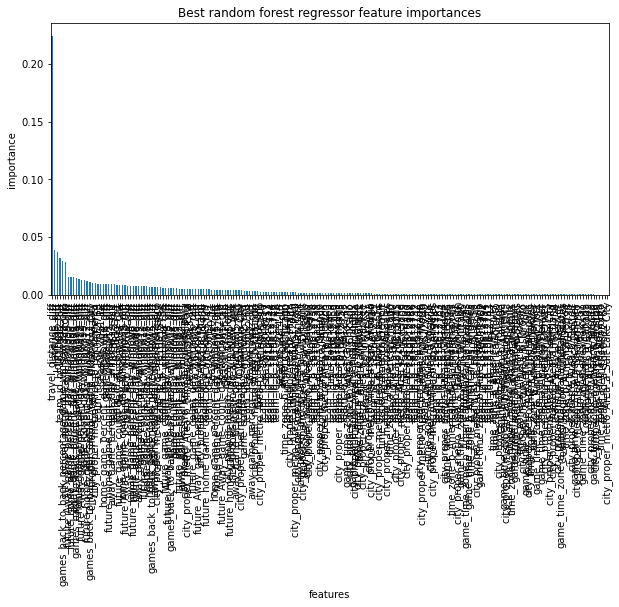

In [33]:
#Code task 27#
#Plot a barplot of the random forest's feature importances,
#assigning the `feature_importances_` attribute of 
#`rf_grid_cv.best_estimator_.named_steps.randomforestregressor` to the name `imps` to then
#create a pandas Series object of the feature importances, with the index given by the
#training data column names, sorting the values in descending order
plt.subplots(figsize=(10, 5))
imps = model_172_model_training_trial_4.named_steps.randomforestregressor.feature_importances_
rf_feat_imps = pd.Series(imps, index=model_172_model_training_trial_4.X_columns).sort_values(ascending=False)
rf_feat_imps.plot(kind='bar')
plt.xlabel('features')
plt.ylabel('importance')
plt.title('Best random forest regressor feature importances');

In [34]:
rf_feat_imps_top_50_list_trial4 = list(rf_feat_imps[0:50].index)
pl(rf_feat_imps_top_50_list_trial4)

50


['travel_distance_diff',
 'latitude_diff',
 'longitude_diff',
 'team_id_b_1610612759',
 'games_back_to_back_percentage_game_window999_diff',
 'city_proper_metro_Area_b_San Antonio',
 'future_Away_game_percent_day_window999_diff',
 'future_home_game_percent_day_window999_diff',
 'away_game_percent_day_window999_diff',
 'games_back_to_back_count_game_window999_diff',
 'home_game_percent_day_window999_diff',
 'future_Away_game_percent_day_window12_diff',
 'game_count_day_window999_diff',
 'future_home_game_percent_day_window12_diff',
 'games_back_to_back_percentage_game_window12_diff',
 'city_proper_metro_Area_b_Oklahoma City',
 'city_proper_metro_Area_b_Sacramento',
 'team_id_b_1610612760',
 'season_2011-12',
 'home_game_percent_day_window12_diff',
 'game_date_diff_diff',
 'future_home_game_count_day_window12_diff',
 'away_game_percent_day_window12_diff',
 'team_id_a_1610612744',
 'team_id_a_1610612751',
 'future_game_count_day_window999_diff',
 'home_game_count_day_window999_diff',
 'fu

In [35]:
rf_feat_imps_top_50_list_trial4_gitiatiab = rf_feat_imps_top_50_list_trial4 + \
                                            ['game_id', 'team_id_a', 'team_id_b']

pl(rf_feat_imps_top_50_list_trial4_gitiatiab)


53


['travel_distance_diff',
 'latitude_diff',
 'longitude_diff',
 'team_id_b_1610612759',
 'games_back_to_back_percentage_game_window999_diff',
 'city_proper_metro_Area_b_San Antonio',
 'future_Away_game_percent_day_window999_diff',
 'future_home_game_percent_day_window999_diff',
 'away_game_percent_day_window999_diff',
 'games_back_to_back_count_game_window999_diff',
 'home_game_percent_day_window999_diff',
 'future_Away_game_percent_day_window12_diff',
 'game_count_day_window999_diff',
 'future_home_game_percent_day_window12_diff',
 'games_back_to_back_percentage_game_window12_diff',
 'city_proper_metro_Area_b_Oklahoma City',
 'city_proper_metro_Area_b_Sacramento',
 'team_id_b_1610612760',
 'season_2011-12',
 'home_game_percent_day_window12_diff',
 'game_date_diff_diff',
 'future_home_game_count_day_window12_diff',
 'away_game_percent_day_window12_diff',
 'team_id_a_1610612744',
 'team_id_a_1610612751',
 'future_game_count_day_window999_diff',
 'home_game_count_day_window999_diff',
 'fu

In [36]:
scaled_df_top_50 = \
scaled_df_top_50_features_with_categorical_dummy_variables.loc[:, rf_feat_imps_top_50_list_trial4]

p(scaled_df_top_50)

(10266, 50)


,travel_distance_diff,latitude_diff,longitude_diff,team_id_b_1610612759,games_back_to_back_percentage_game_window999_diff,city_proper_metro_Area_b_San Antonio,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,away_game_percent_day_window999_diff,games_back_to_back_count_game_window999_diff,home_game_percent_day_window999_diff,future_Away_game_percent_day_window12_diff,game_count_day_window999_diff,future_home_game_percent_day_window12_diff,games_back_to_back_percentage_game_window12_diff,city_proper_metro_Area_b_Oklahoma City,city_proper_metro_Area_b_Sacramento,team_id_b_1610612760,season_2011-12,home_game_percent_day_window12_diff,game_date_diff_diff,future_home_game_count_day_window12_diff,away_game_percent_day_window12_diff,team_id_a_1610612744,team_id_a_1610612751,future_game_count_day_window999_diff,home_game_count_day_window999_diff,future_Away_game_percent_day_window8_diff,team_id_b_1610612758,away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window999_diff,game_count_day_window12_diff,future_game_count_day_window12_diff,home_game_count_day_window8_diff,home_game_count_day_window12_diff,games_back_to_back_percentage_game_window5_diff,away_game_count_day_window12_diff,city_proper_metro_Area_a_San Francisco,team_id_a_1610612747,team_id_b_1610612755,future_game_count_day_window8_diff,future_Away_game_count_day_window8_diff,games_back_to_back_count_game_window12_diff,game_count_day_window8_diff,game_count_day_window5_diff,future_game_count_day_window2_diff,away_game_count_day_window2_diff,city_proper_metro_Area_b_Philadelphia
0,-1.045984,2.249661,0.309284,0,-0.016676,0,0.009482,-0.009482,-6.465582,-0.052324,6.465582,-0.778288,0.010356,0.778288,-0.007252,0,0,0,0,3.197979,-0.016167,0.608012,-3.197979,0,0,-0.012572,0.499961,-0.261653,0,-2.477298,0.261653,2.477298,-0.433034,0.014199,-1.045520,0.656838,0.592052,-0.003691,-0.537609,0,0,0,-1.212704,-0.623967,-0.008491,0.014907,0.014752,0.002585,-0.873972,0
1,0.835137,-1.609206,0.383027,0,-0.016676,0,0.009482,-0.009482,6.416819,-0.052324,-6.416819,-0.560672,0.010356,0.560672,-0.007252,0,0,0,0,-3.178224,-0.016167,0.003533,3.178224,0,0,-0.012572,-0.493093,-0.347263,0,2.447929,0.347263,-2.447929,0.440350,0.014199,-2.094206,-0.645925,-0.590669,-0.003691,0.551721,0,0,0,-2.438905,-1.247085,-0.008491,0.014907,0.014752,-1.892685,0.876529,0
2,1.138839,-0.562003,1.001028,0,-0.016676,0,0.009482,-0.009482,6.416819,-0.052324,-6.416819,0.869375,0.010356,-0.869375,-0.007252,0,0,0,0,-3.178224,-0.016167,-1.205425,3.178224,0,0,-0.012572,-0.493093,1.065297,0,2.447929,-1.065297,-2.447929,0.440350,0.014199,-1.045520,-0.645925,-0.590669,-0.003691,0.551721,0,0,0,-1.212704,0.622268,-0.008491,0.014907,0.014752,1.897854,0.876529,0
3,-1.256725,0.877570,1.270549,0,-0.016676,0,0.009482,-0.009482,-6.465582,-0.052324,6.465582,0.232071,0.010356,-0.232071,-0.007252,0,1,0,0,3.197979,-0.016167,0.003533,-3.197979,0,0,-0.012572,0.499961,-0.004824,1,-2.477298,0.004824,2.477298,-0.433034,0.014199,1.051853,0.656838,0.592052,-0.003691,-0.537609,0,0,0,0.013497,-0.000850,-0.008491,0.014907,0.014752,0.002585,-0.873972,0
4,0.848535,-1.892884,-0.403891,0,6.083854,0,-0.030497,0.030497,6.416819,0.414362,-6.416819,0.232071,0.687540,-0.232071,4.133512,0,0,0,0,-3.178224,-6.722156,-0.600946,3.178224,0,0,-0.706445,-0.493093,0.252005,0,2.447929,-0.252005,-2.447929,0.877042,1.019453,-1.045520,-0.645925,-0.590669,2.735631,1.096386,0,0,1,-1.212704,-0.000850,0.762917,1.192078,1.560055,0.002585,1.751780,1
10261,1.359732,1.106411,-1.506188,0,-0.016676,0,0.009482,-0.009482,0.040681,-0.052324,-0.040681,-0.001089,0.010356,0.001089,-0.007252,0,0,0,0,0.647498,-0.016167,0.003533,-0.647498,1,0,-0.012572,-0.493093,-0.004824,0,-0.014685,0.004824,0.014685,0.440350,0.014199,0.003167,0.005457,0.592052,-0.003691,-0.537609,1,0,0,0.013497,-0.000850,-0.008491,0.014907,0.014752,0.002585,0.876529,0
10262,1.789289,0.507847,1.893345,0,-0.1543

In [37]:
df.loc[:,['game_id', 'team_id_a', 'team_id_b']]

,game_id,team_id_a,team_id_b
0,21000001,1610612738,1610612748
1,21000002,1610612756,1610612757
2,21000003,1610612745,1610612747
3,21000009,1610612750,1610612758
4,21000006,1610612748,1610612755
...,...,...,...
10261,41700317,1610612744,1610612745
10262,41700401,1610612739,1610612744
10263,41700402,1610612739,1610612744
10264,41700403,1610612739,1610612744


In [38]:
scaled_df_top_50_game_id_team_id_a_team_id_b = \
pd.concat([df.loc[:,['game_id', 'team_id_a', 'team_id_b']], scaled_df_top_50], axis=1)

p(scaled_df_top_50_game_id_team_id_a_team_id_b)

(10266, 53)


,game_id,team_id_a,team_id_b,travel_distance_diff,latitude_diff,longitude_diff,team_id_b_1610612759,games_back_to_back_percentage_game_window999_diff,city_proper_metro_Area_b_San Antonio,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,away_game_percent_day_window999_diff,games_back_to_back_count_game_window999_diff,home_game_percent_day_window999_diff,future_Away_game_percent_day_window12_diff,game_count_day_window999_diff,future_home_game_percent_day_window12_diff,games_back_to_back_percentage_game_window12_diff,city_proper_metro_Area_b_Oklahoma City,city_proper_metro_Area_b_Sacramento,team_id_b_1610612760,season_2011-12,home_game_percent_day_window12_diff,game_date_diff_diff,future_home_game_count_day_window12_diff,away_game_percent_day_window12_diff,team_id_a_1610612744,team_id_a_1610612751,future_game_count_day_window999_diff,home_game_count_day_window999_diff,future_Away_game_percent_day_window8_diff,team_id_b_1610612758,away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window999_diff,game_count_day_window12_diff,future_game_count_day_window12_diff,home_game_count_day_window8_diff,home_game_count_day_window12_diff,games_back_to_back_percentage_game_window5_diff,away_game_count_day_window12_diff,city_proper_metro_Area_a_San Francisco,team_id_a_1610612747,team_id_b_1610612755,future_game_count_day_window8_diff,future_Away_game_count_day_window8_diff,games_back_to_back_count_game_window12_diff,game_count_day_window8_diff,game_count_day_window5_diff,future_game_count_day_window2_diff,away_game_count_day_window2_diff,city_proper_metro_Area_b_Philadelphia
0,21000001,1610612738,1610612748,-1.045984,2.249661,0.309284,0,-0.016676,0,0.009482,-0.009482,-6.465582,-0.052324,6.465582,-0.778288,0.010356,0.778288,-0.007252,0,0,0,0,3.197979,-0.016167,0.608012,-3.197979,0,0,-0.012572,0.499961,-0.261653,0,-2.477298,0.261653,2.477298,-0.433034,0.014199,-1.045520,0.656838,0.592052,-0.003691,-0.537609,0,0,0,-1.212704,-0.623967,-0.008491,0.014907,0.014752,0.002585,-0.873972,0
1,21000002,1610612756,1610612757,0.835137,-1.609206,0.383027,0,-0.016676,0,0.009482,-0.009482,6.416819,-0.052324,-6.416819,-0.560672,0.010356,0.560672,-0.007252,0,0,0,0,-3.178224,-0.016167,0.003533,3.178224,0,0,-0.012572,-0.493093,-0.347263,0,2.447929,0.347263,-2.447929,0.440350,0.014199,-2.094206,-0.645925,-0.590669,-0.003691,0.551721,0,0,0,-2.438905,-1.247085,-0.008491,0.014907,0.014752,-1.892685,0.876529,0
2,21000003,1610612745,1610612747,1.138839,-0.562003,1.001028,0,-0.016676,0,0.009482,-0.009482,6.416819,-0.052324,-6.416819,0.869375,0.010356,-0.869375,-0.007252,0,0,0,0,-3.178224,-0.016167,-1.205425,3.178224,0,0,-0.012572,-0.493093,1.065297,0,2.447929,-1.065297,-2.447929,0.440350,0.014199,-1.045520,-0.645925,-0.590669,-0.003691,0.551721,0,0,0,-1.212704,0.622268,-0.008491,0.014907,0.014752,1.897854,0.876529,0
3,21000009,1610612750,1610612758,-1.256725,0.877570,1.270549,0,-0.016676,0,0.009482,-0.009482,-6.465582,-0.052324,6.465582,0.232071,0.010356,-0.232071,-0.007252,0,1,0,0,3.197979,-0.016167,0.003533,-3.197979,0,0,-0.012572,0.499961,-0.004824,1,-2.477298,0.004824,2.477298,-0.433034,0.014199,1.051853,0.656838,0.592052,-0.003691,-0.537609,0,0,0,0.013497,-0.000850,-0.008491,0.014907,0.014752,0.002585,-0.873972,0
4,21000006,1610612748,1610612755,0.848535,-1.892884,-0.403891,0,6.083854,0,-0.030497,0.030497,6.416819,0.414362,-6.416819,0.232071,0.687540,-0.232071,4.133512,0,0,0,0,-3.178224,-6.722156,-0.600946,3.178224,0,0,-0.706445,-0.493093,0.252005,0,2.447929,-0.252005,-2.447929,0.877042,1.019453,-1.045520,-0.645925,-0.590669,2.735631,1.096386,0,0,1,-1.212704,-0.000850,0.762917,1.192078,1.560055,0.002585,1.751780,1
10261,41700317,1610612744,1610612745,1.359732,1.106411,-1.506188,0,-0.016676,0,0.009482,-0.009482,0.040681,-0.052324,-0.040681,-0.001089,0.010356,0.001089,-0.007252,0,0,0,0,0.647498,-0.016167,0.003533,-0.647498,1,0,-0.012572,-0.493093,-0.004

In [39]:
X_train, X_test, y_train, y_test = train_test_split(scaled_df_top_50_game_id_team_id_a_team_id_b, 
                                                    df_target,
                                                    test_size=0.1, 
                                                    random_state=random_state_2909,
                                                    shuffle=False)

In [40]:
X_train.shape

(9239, 53)

In [41]:
y_train.shape

(9239, 1)

In [42]:
X_test.shape

(1027, 53)

In [43]:
y_test.shape

(1027, 1)

In [44]:
df_train = pd.concat([X_train, y_train], axis=1)
p(df_train)

(9239, 54)


,game_id,team_id_a,team_id_b,travel_distance_diff,latitude_diff,longitude_diff,team_id_b_1610612759,games_back_to_back_percentage_game_window999_diff,city_proper_metro_Area_b_San Antonio,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,away_game_percent_day_window999_diff,games_back_to_back_count_game_window999_diff,home_game_percent_day_window999_diff,future_Away_game_percent_day_window12_diff,game_count_day_window999_diff,future_home_game_percent_day_window12_diff,games_back_to_back_percentage_game_window12_diff,city_proper_metro_Area_b_Oklahoma City,city_proper_metro_Area_b_Sacramento,team_id_b_1610612760,season_2011-12,home_game_percent_day_window12_diff,game_date_diff_diff,future_home_game_count_day_window12_diff,away_game_percent_day_window12_diff,team_id_a_1610612744,team_id_a_1610612751,future_game_count_day_window999_diff,home_game_count_day_window999_diff,future_Away_game_percent_day_window8_diff,team_id_b_1610612758,away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window999_diff,game_count_day_window12_diff,future_game_count_day_window12_diff,home_game_count_day_window8_diff,home_game_count_day_window12_diff,games_back_to_back_percentage_game_window5_diff,away_game_count_day_window12_diff,city_proper_metro_Area_a_San Francisco,team_id_a_1610612747,team_id_b_1610612755,future_game_count_day_window8_diff,future_Away_game_count_day_window8_diff,games_back_to_back_count_game_window12_diff,game_count_day_window8_diff,game_count_day_window5_diff,future_game_count_day_window2_diff,away_game_count_day_window2_diff,city_proper_metro_Area_b_Philadelphia,spread_a
0,21000001,1610612738,1610612748,-1.045984,2.249661,0.309284,0,-0.016676,0,0.009482,-0.009482,-6.465582,-0.052324,6.465582,-0.778288,0.010356,0.778288,-0.007252,0,0,0,0,3.197979,-0.016167,0.608012,-3.197979,0,0,-0.012572,0.499961,-0.261653,0,-2.477298,0.261653,2.477298,-0.433034,0.014199,-1.045520,0.656838,0.592052,-0.003691,-0.537609,0,0,0,-1.212704,-0.623967,-0.008491,0.014907,0.014752,0.002585,-0.873972,0,-8
1,21000002,1610612756,1610612757,0.835137,-1.609206,0.383027,0,-0.016676,0,0.009482,-0.009482,6.416819,-0.052324,-6.416819,-0.560672,0.010356,0.560672,-0.007252,0,0,0,0,-3.178224,-0.016167,0.003533,3.178224,0,0,-0.012572,-0.493093,-0.347263,0,2.447929,0.347263,-2.447929,0.440350,0.014199,-2.094206,-0.645925,-0.590669,-0.003691,0.551721,0,0,0,-2.438905,-1.247085,-0.008491,0.014907,0.014752,-1.892685,0.876529,0,14
2,21000003,1610612745,1610612747,1.138839,-0.562003,1.001028,0,-0.016676,0,0.009482,-0.009482,6.416819,-0.052324,-6.416819,0.869375,0.010356,-0.869375,-0.007252,0,0,0,0,-3.178224,-0.016167,-1.205425,3.178224,0,0,-0.012572,-0.493093,1.065297,0,2.447929,-1.065297,-2.447929,0.440350,0.014199,-1.045520,-0.645925,-0.590669,-0.003691,0.551721,0,0,0,-1.212704,0.622268,-0.008491,0.014907,0.014752,1.897854,0.876529,0,2
3,21000009,1610612750,1610612758,-1.256725,0.877570,1.270549,0,-0.016676,0,0.009482,-0.009482,-6.465582,-0.052324,6.465582,0.232071,0.010356,-0.232071,-0.007252,0,1,0,0,3.197979,-0.016167,0.003533,-3.197979,0,0,-0.012572,0.499961,-0.004824,1,-2.477298,0.004824,2.477298,-0.433034,0.014199,1.051853,0.656838,0.592052,-0.003691,-0.537609,0,0,0,0.013497,-0.000850,-0.008491,0.014907,0.014752,0.002585,-0.873972,0,1
4,21000006,1610612748,1610612755,0.848535,-1.892884,-0.403891,0,6.083854,0,-0.030497,0.030497,6.416819,0.414362,-6.416819,0.232071,0.687540,-0.232071,4.133512,0,0,0,0,-3.178224,-6.722156,-0.600946,3.178224,0,0,-0.706445,-0.493093,0.252005,0,2.447929,-0.252005,-2.447929,0.877042,1.019453,-1.045520,-0.645925,-0.590669,2.735631,1.096386,0,0,1,-1.212704,-0.000850,0.762917,1.192078,1.560055,0.002585,1.751780,1,-10
9234,21700279,1610612757,1610612764,1.950338,0.908407,-2.448327,0,1.781375,0,0.163685,-0.163685,-0.176936,1.347733,0.176936,-0.871552,0.687540,0.871552,1.373003,0,0,0,0,-0.141937,-1.692664,0.608012,0.141937,0,0,-0.7064

In [45]:
df_test = pd.concat([X_test, y_test], axis=1)
p(df_test)

(1027, 54)


,game_id,team_id_a,team_id_b,travel_distance_diff,latitude_diff,longitude_diff,team_id_b_1610612759,games_back_to_back_percentage_game_window999_diff,city_proper_metro_Area_b_San Antonio,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,away_game_percent_day_window999_diff,games_back_to_back_count_game_window999_diff,home_game_percent_day_window999_diff,future_Away_game_percent_day_window12_diff,game_count_day_window999_diff,future_home_game_percent_day_window12_diff,games_back_to_back_percentage_game_window12_diff,city_proper_metro_Area_b_Oklahoma City,city_proper_metro_Area_b_Sacramento,team_id_b_1610612760,season_2011-12,home_game_percent_day_window12_diff,game_date_diff_diff,future_home_game_count_day_window12_diff,away_game_percent_day_window12_diff,team_id_a_1610612744,team_id_a_1610612751,future_game_count_day_window999_diff,home_game_count_day_window999_diff,future_Away_game_percent_day_window8_diff,team_id_b_1610612758,away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window999_diff,game_count_day_window12_diff,future_game_count_day_window12_diff,home_game_count_day_window8_diff,home_game_count_day_window12_diff,games_back_to_back_percentage_game_window5_diff,away_game_count_day_window12_diff,city_proper_metro_Area_a_San Francisco,team_id_a_1610612747,team_id_b_1610612755,future_game_count_day_window8_diff,future_Away_game_count_day_window8_diff,games_back_to_back_count_game_window12_diff,game_count_day_window8_diff,game_count_day_window5_diff,future_game_count_day_window2_diff,away_game_count_day_window2_diff,city_proper_metro_Area_b_Philadelphia,spread_a
9239,21700285,1610612749,1610612762,1.028423,0.322683,1.055866,0,-0.423378,0,-0.094902,0.094902,0.619739,-0.519009,-0.619739,1.086991,-1.344011,-1.086991,-0.007252,0,0,0,0,0.222418,-0.016167,-1.205425,-0.222418,0,0,1.375175,-1.486146,1.279321,0,0.600969,-1.279321,-0.600969,0.440350,-0.991056,0.003167,-0.645925,0.000691,-1.099420,-0.537609,0,0,0,0.013497,1.245386,-0.008491,0.014907,0.014752,0.002585,0.876529,0,13
9240,21700287,1610612741,1610612748,-0.989872,2.184396,-0.524758,0,1.374673,0,-0.239616,0.239616,0.521802,0.881048,-0.521802,-1.089168,-0.666828,1.089168,1.373003,0,0,0,0,-0.673287,-0.016167,1.212491,0.673287,0,0,0.681302,-0.989619,-0.903726,0,0.724099,0.903726,-0.724099,0.440350,1.019453,0.003167,-0.645925,-0.590669,1.092038,1.096386,0,0,0,-1.212704,-1.247085,1.534324,1.192078,0.014752,0.002585,-0.873972,0,7
9241,21700289,1610612751,1610612763,0.792883,0.757034,0.660032,0,0.625485,0,-0.091714,0.091714,0.653640,0.414362,-0.653640,0.542951,0.010356,-0.542951,0.682875,0,0,0,0,-0.734013,-0.016167,-0.600946,0.734013,0,1,-0.012572,-0.989619,0.637248,0,0.600969,-0.637248,-0.600969,0.877042,-0.991056,0.003167,-0.645925,-1.182030,-0.003691,0.551721,0,0,0,0.013497,0.622268,0.762917,0.014907,0.014752,1.897854,0.876529,0,-10
9242,21700288,1610612750,1610612756,-1.063182,1.568692,0.796300,0,-1.091531,0,-0.355300,0.355300,0.742428,-0.985695,-0.742428,-0.933728,-0.666828,0.933728,-0.697380,0,0,0,0,0.161692,-0.016167,1.212491,-0.161692,0,0,0.681302,-1.486146,-1.545799,0,-0.137815,1.545799,0.137815,0.877042,1.019453,0.003167,0.656838,0.592052,-0.003691,0.007056,0,0,0,1.239698,-1.247085,-0.779899,1.192078,0.014752,0.002585,-0.873972,0,-11
9243,21700292,1610612738,1610612765,-0.509033,0.020163,0.452923,0,-0.921539,0,-0.149777,0.149777,0.098895,-0.519009,-0.098895,-1.788648,2.041908,1.788648,-0.007252,0,0,0,0,0.738587,-0.854416,1.816969,-0.738587,0,0,-2.094192,0.499961,-2.059457,0,-0.178859,2.059457,0.178859,0.877042,2.024708,-1.045520,0.656838,1.183412,-0.003691,0.007056,0,0,0,-1.212704,-2.493320,-0.008491,2.369250,1.560055,0.002585,-0.873972,0,10
10261,41700317,1610612744,1610612745,1.359732,1.106411,-1.506188,0,-0.016676,0,0.009482,-0.009482,0.040681,-0.052324,-0.040681,-0.001089,0.010356,0.001089,-0.007252,0,0,0,0,0.647498,-0.016167,0.003533,-0.647498,1,0

In [46]:
datapath = os.path.join('..', 'processed_data')

if not os.path.exists(datapath):
    os.mkdir(datapath)

datapath_df = os.path.join(datapath, 
                           '173A_train_split_time_series_172_trial4_top_50_trial_1_game_id_team_id_a_team_id_b.csv')
if not os.path.exists(datapath_df):
    df_train.to_csv(datapath_df, index=True)

In [47]:
datapath = os.path.join('..', 'processed_data')

if not os.path.exists(datapath):
    os.mkdir(datapath)

datapath_df = os.path.join(datapath, 
                           '173A_test_split_time_series_172_trial4_top_50_trial_1_game_id_team_id_a_team_id_b.csv')
if not os.path.exists(datapath_df):
    df_test.to_csv(datapath_df, index=True)

In [48]:
df_train_readback = \
rcp('173A_train_split_time_series_172_trial4_top_50_trial_1_game_id_team_id_a_team_id_b.csv', None, 0)

p(df_train_readback)

(9239, 54)


,game_id,team_id_a,team_id_b,travel_distance_diff,latitude_diff,longitude_diff,team_id_b_1610612759,games_back_to_back_percentage_game_window999_diff,city_proper_metro_Area_b_San Antonio,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,away_game_percent_day_window999_diff,games_back_to_back_count_game_window999_diff,home_game_percent_day_window999_diff,future_Away_game_percent_day_window12_diff,game_count_day_window999_diff,future_home_game_percent_day_window12_diff,games_back_to_back_percentage_game_window12_diff,city_proper_metro_Area_b_Oklahoma City,city_proper_metro_Area_b_Sacramento,team_id_b_1610612760,season_2011-12,home_game_percent_day_window12_diff,game_date_diff_diff,future_home_game_count_day_window12_diff,away_game_percent_day_window12_diff,team_id_a_1610612744,team_id_a_1610612751,future_game_count_day_window999_diff,home_game_count_day_window999_diff,future_Away_game_percent_day_window8_diff,team_id_b_1610612758,away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window999_diff,game_count_day_window12_diff,future_game_count_day_window12_diff,home_game_count_day_window8_diff,home_game_count_day_window12_diff,games_back_to_back_percentage_game_window5_diff,away_game_count_day_window12_diff,city_proper_metro_Area_a_San Francisco,team_id_a_1610612747,team_id_b_1610612755,future_game_count_day_window8_diff,future_Away_game_count_day_window8_diff,games_back_to_back_count_game_window12_diff,game_count_day_window8_diff,game_count_day_window5_diff,future_game_count_day_window2_diff,away_game_count_day_window2_diff,city_proper_metro_Area_b_Philadelphia,spread_a
0,21000001,1610612738,1610612748,-1.045984,2.249661,0.309284,0,-0.016676,0,0.009482,-0.009482,-6.465582,-0.052324,6.465582,-0.778288,0.010356,0.778288,-0.007252,0,0,0,0,3.197979,-0.016167,0.608012,-3.197979,0,0,-0.012572,0.499961,-0.261653,0,-2.477298,0.261653,2.477298,-0.433034,0.014199,-1.045520,0.656838,0.592052,-0.003691,-0.537609,0,0,0,-1.212704,-0.623967,-0.008491,0.014907,0.014752,0.002585,-0.873972,0,-8
1,21000002,1610612756,1610612757,0.835137,-1.609206,0.383027,0,-0.016676,0,0.009482,-0.009482,6.416819,-0.052324,-6.416819,-0.560672,0.010356,0.560672,-0.007252,0,0,0,0,-3.178224,-0.016167,0.003533,3.178224,0,0,-0.012572,-0.493093,-0.347263,0,2.447929,0.347263,-2.447929,0.440350,0.014199,-2.094206,-0.645925,-0.590669,-0.003691,0.551721,0,0,0,-2.438905,-1.247085,-0.008491,0.014907,0.014752,-1.892685,0.876529,0,14
2,21000003,1610612745,1610612747,1.138839,-0.562003,1.001028,0,-0.016676,0,0.009482,-0.009482,6.416819,-0.052324,-6.416819,0.869375,0.010356,-0.869375,-0.007252,0,0,0,0,-3.178224,-0.016167,-1.205425,3.178224,0,0,-0.012572,-0.493093,1.065297,0,2.447929,-1.065297,-2.447929,0.440350,0.014199,-1.045520,-0.645925,-0.590669,-0.003691,0.551721,0,0,0,-1.212704,0.622268,-0.008491,0.014907,0.014752,1.897854,0.876529,0,2
3,21000009,1610612750,1610612758,-1.256725,0.877570,1.270549,0,-0.016676,0,0.009482,-0.009482,-6.465582,-0.052324,6.465582,0.232071,0.010356,-0.232071,-0.007252,0,1,0,0,3.197979,-0.016167,0.003533,-3.197979,0,0,-0.012572,0.499961,-0.004824,1,-2.477298,0.004824,2.477298,-0.433034,0.014199,1.051853,0.656838,0.592052,-0.003691,-0.537609,0,0,0,0.013497,-0.000850,-0.008491,0.014907,0.014752,0.002585,-0.873972,0,1
4,21000006,1610612748,1610612755,0.848535,-1.892884,-0.403891,0,6.083854,0,-0.030497,0.030497,6.416819,0.414362,-6.416819,0.232071,0.687540,-0.232071,4.133512,0,0,0,0,-3.178224,-6.722156,-0.600946,3.178224,0,0,-0.706445,-0.493093,0.252005,0,2.447929,-0.252005,-2.447929,0.877042,1.019453,-1.045520,-0.645925,-0.590669,2.735631,1.096386,0,0,1,-1.212704,-0.000850,0.762917,1.192078,1.560055,0.002585,1.751780,1,-10
9234,21700279,1610612757,1610612764,1.950338,0.908407,-2.448327,0,1.781375,0,0.163685,-0.163685,-0.176936,1.347733,0.176936,-0.871552,0.687540,0.871552,1.373003,0,0,0,0,-0.141937,-1.692664,0.608012,0.141937,0,0,-0.7064

In [49]:
df_test_readback = \
rcp('173A_test_split_time_series_172_trial4_top_50_trial_1_game_id_team_id_a_team_id_b.csv', None, 0)

p(df_test_readback)

(1027, 54)


,game_id,team_id_a,team_id_b,travel_distance_diff,latitude_diff,longitude_diff,team_id_b_1610612759,games_back_to_back_percentage_game_window999_diff,city_proper_metro_Area_b_San Antonio,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,away_game_percent_day_window999_diff,games_back_to_back_count_game_window999_diff,home_game_percent_day_window999_diff,future_Away_game_percent_day_window12_diff,game_count_day_window999_diff,future_home_game_percent_day_window12_diff,games_back_to_back_percentage_game_window12_diff,city_proper_metro_Area_b_Oklahoma City,city_proper_metro_Area_b_Sacramento,team_id_b_1610612760,season_2011-12,home_game_percent_day_window12_diff,game_date_diff_diff,future_home_game_count_day_window12_diff,away_game_percent_day_window12_diff,team_id_a_1610612744,team_id_a_1610612751,future_game_count_day_window999_diff,home_game_count_day_window999_diff,future_Away_game_percent_day_window8_diff,team_id_b_1610612758,away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window999_diff,game_count_day_window12_diff,future_game_count_day_window12_diff,home_game_count_day_window8_diff,home_game_count_day_window12_diff,games_back_to_back_percentage_game_window5_diff,away_game_count_day_window12_diff,city_proper_metro_Area_a_San Francisco,team_id_a_1610612747,team_id_b_1610612755,future_game_count_day_window8_diff,future_Away_game_count_day_window8_diff,games_back_to_back_count_game_window12_diff,game_count_day_window8_diff,game_count_day_window5_diff,future_game_count_day_window2_diff,away_game_count_day_window2_diff,city_proper_metro_Area_b_Philadelphia,spread_a
9239,21700285,1610612749,1610612762,1.028423,0.322683,1.055866,0,-0.423378,0,-0.094902,0.094902,0.619739,-0.519009,-0.619739,1.086991,-1.344011,-1.086991,-0.007252,0,0,0,0,0.222418,-0.016167,-1.205425,-0.222418,0,0,1.375175,-1.486146,1.279321,0,0.600969,-1.279321,-0.600969,0.440350,-0.991056,0.003167,-0.645925,0.000691,-1.099420,-0.537609,0,0,0,0.013497,1.245386,-0.008491,0.014907,0.014752,0.002585,0.876529,0,13
9240,21700287,1610612741,1610612748,-0.989872,2.184396,-0.524758,0,1.374673,0,-0.239616,0.239616,0.521802,0.881048,-0.521802,-1.089168,-0.666828,1.089168,1.373003,0,0,0,0,-0.673287,-0.016167,1.212491,0.673287,0,0,0.681302,-0.989619,-0.903726,0,0.724099,0.903726,-0.724099,0.440350,1.019453,0.003167,-0.645925,-0.590669,1.092038,1.096386,0,0,0,-1.212704,-1.247085,1.534324,1.192078,0.014752,0.002585,-0.873972,0,7
9241,21700289,1610612751,1610612763,0.792883,0.757034,0.660032,0,0.625485,0,-0.091714,0.091714,0.653640,0.414362,-0.653640,0.542951,0.010356,-0.542951,0.682875,0,0,0,0,-0.734013,-0.016167,-0.600946,0.734013,0,1,-0.012572,-0.989619,0.637248,0,0.600969,-0.637248,-0.600969,0.877042,-0.991056,0.003167,-0.645925,-1.182030,-0.003691,0.551721,0,0,0,0.013497,0.622268,0.762917,0.014907,0.014752,1.897854,0.876529,0,-10
9242,21700288,1610612750,1610612756,-1.063182,1.568692,0.796300,0,-1.091531,0,-0.355300,0.355300,0.742428,-0.985695,-0.742428,-0.933728,-0.666828,0.933728,-0.697380,0,0,0,0,0.161692,-0.016167,1.212491,-0.161692,0,0,0.681302,-1.486146,-1.545799,0,-0.137815,1.545799,0.137815,0.877042,1.019453,0.003167,0.656838,0.592052,-0.003691,0.007056,0,0,0,1.239698,-1.247085,-0.779899,1.192078,0.014752,0.002585,-0.873972,0,-11
9243,21700292,1610612738,1610612765,-0.509033,0.020163,0.452923,0,-0.921539,0,-0.149777,0.149777,0.098895,-0.519009,-0.098895,-1.788648,2.041908,1.788648,-0.007252,0,0,0,0,0.738587,-0.854416,1.816969,-0.738587,0,0,-2.094192,0.499961,-2.059457,0,-0.178859,2.059457,0.178859,0.877042,2.024708,-1.045520,0.656838,1.183412,-0.003691,0.007056,0,0,0,-1.212704,-2.493320,-0.008491,2.369250,1.560055,0.002585,-0.873972,0,10
10261,41700317,1610612744,1610612745,1.359732,1.106411,-1.506188,0,-0.016676,0,0.009482,-0.009482,0.040681,-0.052324,-0.040681,-0.001089,0.010356,0.001089,-0.007252,0,0,0,0,0.647498,-0.016167,0.003533,-0.647498,1,0